# LSTM Heart Sound Classification

## Yaseen Khan Dataset — Conv1D-LSTM Architecture

## GPU Setup

In [4]:
import os
import tensorflow as tf

os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    try:
        for gpu in physical_devices:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f'GPU Memory Growth Enabled for: {physical_devices}')
    except RuntimeError as e:
        print(f'GPU Error: {e}')
else:
    print('No GPU detected. Running on CPU.')


GPU Memory Growth Enabled for: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Foundation Set Up and Configuration

In [6]:
import os
import numpy as np
import librosa
import librosa.display
import scipy.signal as signal
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
import warnings
from cryptography.utils import CryptographyDeprecationWarning

warnings.filterwarnings('ignore', category=CryptographyDeprecationWarning)
np.random.seed(42)
print('Libraries imported successfully!')

# --- CONFIGURATION (Yaseen Khan Dataset) ---
BASE_PATH = r'C:\Users\emirh\Downloads\FYP2\Models_Yaseen\Classification-of-Heart-Sound\HeartData'

# Yaseen Khan Dataset — 5 class folders inside HeartData
# Each folder name maps to one heart sound class:
#   N_New_3주기   -> Normal
#   MVP_New_3주기 -> Mitral Valve Prolapse
#   MS_New_3주기  -> Mitral Stenosis
#   MR_New_3주기  -> Mitral Regurgitation
#   AS_New_3주기  -> Aortic Stenosis
FOLDERS = [
    "N_New_3\uc8fc\uae30",    # Normal
    "MVP_New_3\uc8fc\uae30",  # Mitral Valve Prolapse
    "MS_New_3\uc8fc\uae30",   # Mitral Stenosis
    "MR_New_3\uc8fc\uae30",   # Mitral Regurgitation
    "AS_New_3\uc8fc\uae30"    # Aortic Stenosis
]

# Label mapping (integer -> class name)
CLASS_NAMES = {
    0: 'Normal',
    1: 'MVP',
    2: 'MS',
    3: 'MR',
    4: 'AS'
}

# Folder name -> integer label
FOLDER_LABEL_MAP = {
    "N_New_3\uc8fc\uae30": 0,
    "MVP_New_3\uc8fc\uae30": 1,
    "MS_New_3\uc8fc\uae30": 2,
    "MR_New_3\uc8fc\uae30": 3,
    "AS_New_3\uc8fc\uae30": 4
}

SAMPLE_RATE = 16000
DURATION = 5
SAMPLES_PER_TRACK = SAMPLE_RATE * DURATION

print(f'BASE_PATH : {BASE_PATH}')
print(f'FOLDERS   : {FOLDERS}')
print(f'Classes   : {list(CLASS_NAMES.values())}')
print(f'SAMPLE_RATE : {SAMPLE_RATE}')
print(f'DURATION    : {DURATION}s')


Libraries imported successfully!
BASE_PATH : C:\Users\emirh\Downloads\FYP2\Models_Yaseen\Classification-of-Heart-Sound\HeartData
FOLDERS   : ['N_New_3주기', 'MVP_New_3주기', 'MS_New_3주기', 'MR_New_3주기', 'AS_New_3주기']
Classes   : ['Normal', 'MVP', 'MS', 'MR', 'AS']
SAMPLE_RATE : 16000
DURATION    : 5s


## Data Augmentation Functions



In [8]:
def butter_bandpass(lowcut, highcut, fs, order=5):
    """Generates the filter coefficients."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = signal.butter(order, [low, high], btype='band')
    return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    """Applies the Bandpass Filter (25-400Hz)."""
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = signal.lfilter(b, a, data)
    return y

def fix_duration_segmentation(data):
    """
    Apply 5-Second Fixed Segmentation.
    - If shorter than 5s: Pad with zeros.
    - If longer than 5s: Truncate.
    """
    if len(data) > SAMPLES_PER_TRACK:
        return data[:SAMPLES_PER_TRACK]
    else:
        padding = SAMPLES_PER_TRACK - len(data)
        return np.pad(data, (0, padding), 'constant')

def z_score_normalize(data):
    """
    Applies Z-Score Normalization (Standardization).
    Result has Mean = 0, Std Dev = 1.
    """
    mean = np.mean(data)
    std = np.std(data)
    if std > 0:
        return (data - mean) / std
    else:
        return data

# AUGMENTATION FUNCTIONS
def add_noise_awgn(data):
    
    sigma = np.sqrt(np.mean(data ** 2))   # RMS of the signal
    noise = np.random.normal(0, sigma, len(data))
    return data + noise

def pitch_shift(data, sampling_rate):
    
    p = np.random.randint(1, 11)          # integer in [1, 10]
    direction = np.random.choice([-1, 1]) # up or down
    n_steps = direction * p
    return librosa.effects.pitch_shift(data, sr=sampling_rate, n_steps=n_steps)

print('Preprocessing and augmentation functions defined.')


Preprocessing and augmentation functions defined.


## Feature Extraction (Mel-Spectrogram — 224×224)


In [10]:
# Mel-spectrogram configuration
N_MELS        = 224
MEL_TIME_STEPS = 224
N_FFT         = 2048
HOP_LENGTH    = 512

def extract_features(audio_data, sample_rate):
    
    mel_spec = librosa.feature.melspectrogram(
        y=audio_data,
        sr=sample_rate,
        n_mels=N_MELS,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH
    )

    # Convert power spectrogram to dB scale
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    # Clip dB range to keep values between -80 and 0
    mel_spec_db = np.clip(mel_spec_db, -80, 0)

    # Pad or truncate along the time axis
    if mel_spec_db.shape[1] < MEL_TIME_STEPS:
        pad_width = MEL_TIME_STEPS - mel_spec_db.shape[1]
        mel_spec_db = np.pad(
            mel_spec_db,
            pad_width=((0, 0), (0, pad_width)),
            mode='constant',
            constant_values=-80
        )
    else:
        mel_spec_db = mel_spec_db[:, :MEL_TIME_STEPS]

    # Transpose to (time_steps, mel_features) = (224, 224)
    mel_spec_db = mel_spec_db.T

    # Normalize from [-80, 0] to [0, 1]
    mel_spec_norm = (mel_spec_db + 80) / 80

    return mel_spec_norm.astype(np.float32)

print('Feature extraction function defined (Normalized Mel-Spectrogram).')
print(f'Output shape per sample: ({MEL_TIME_STEPS}, {N_MELS})')
print('Mel-spectrogram values are normalized to range [0, 1].')


Feature extraction function defined (Normalized Mel-Spectrogram).
Output shape per sample: (224, 224)
Mel-spectrogram values are normalized to range [0, 1].


## Data Preparation (Yaseen Khan Dataset — Mel-Spectrogram — No Augmentation)

In [12]:
from tensorflow.keras.utils import to_categorical
from collections import Counter


file_paths = []
labels = []

# Keep lower-case alias so the processing/evaluation cells remain consistent
class_names = CLASS_NAMES

print('Scanning Yaseen Khan folders...')
for folder_name, label in FOLDER_LABEL_MAP.items():
    folder_path = os.path.join(BASE_PATH, folder_name)

    if not os.path.exists(folder_path):
        print(f'  [WARNING] Folder not found: {folder_path}')
        continue

    for filename in os.listdir(folder_path):
        filename_lower = filename.lower()

        if not filename_lower.endswith('.wav'):
            continue

        file_path = os.path.join(folder_path, filename)
        file_paths.append(file_path)
        labels.append(label)

print(f'\nTotal valid files gathered: {len(labels)}')
distribution = Counter(labels)
print('-' * 35)
print('CLASS DISTRIBUTION (Before Split):')
for label_int in sorted(distribution.keys()):
    print(f' - [{label_int}] {class_names[label_int]:<12}: {distribution[label_int]} files')
print('-' * 35 + '\n')

# ============================================================
# 2. STRATIFIED SPLIT: 70 / 10 / 20
# ============================================================
X_train_val_paths, X_test_paths, y_train_val_labels, y_test_labels = train_test_split(
    file_paths, labels, test_size=0.2, stratify=labels, random_state=42
)

X_train_paths, X_val_paths, y_train_labels, y_val_labels = train_test_split(
    X_train_val_paths, y_train_val_labels, test_size=0.125, stratify=y_train_val_labels, random_state=42
)

print(f'File Counts -> Train: {len(X_train_paths)}, Val: {len(X_val_paths)}, Test: {len(X_test_paths)}')

max_original_class_count = max(distribution.values()) if len(distribution) > 0 else 0
TARGET_COUNTS = {
    0: max_original_class_count,  # Normal
    1: max_original_class_count,  # MVP
    2: max_original_class_count,  # MS
    3: max_original_class_count,  # MR
    4: max_original_class_count   # AS
}

print('\nTARGET_COUNTS for training augmentation:')
for label_int in sorted(TARGET_COUNTS.keys()):
    print(f' - {class_names[label_int]:<12}: {TARGET_COUNTS[label_int]}')


Scanning Yaseen Khan folders...

Total valid files gathered: 1000
-----------------------------------
CLASS DISTRIBUTION (Before Split):
 - [0] Normal      : 200 files
 - [1] MVP         : 200 files
 - [2] MS          : 200 files
 - [3] MR          : 200 files
 - [4] AS          : 200 files
-----------------------------------

File Counts -> Train: 700, Val: 100, Test: 200

TARGET_COUNTS for training augmentation:
 - Normal      : 200
 - MVP         : 200
 - MS          : 200
 - MR          : 200
 - AS          : 200


### Processing Function

In [14]:
def process_data_with_augmentation(X_paths, y_labels, augment=False):
    X_mels = []
    y_final = []

    # Store original preprocessed audio for augmentation
    audio_by_class = {0: [], 1: [], 2: [], 3: [], 4: []}

    print(f'   Processing {len(X_paths)} files (Augment={augment})...')

    # ====================================================
    # STEP 1: Process original files
    # ====================================================
    for i, fpath in enumerate(X_paths):
        try:
            y, sr = librosa.load(fpath, sr=SAMPLE_RATE, duration=DURATION)

            y = butter_bandpass_filter(y, 25, 400, sr)
            y = fix_duration_segmentation(y)
            y = z_score_normalize(y)

            current_label = y_labels[i]

            mel = extract_features(y, sr)

            X_mels.append(mel)
            y_final.append(current_label)

            audio_by_class[current_label].append((y, sr))

        except Exception as e:
            print(f'[SKIPPED ORIGINAL] {fpath} -> {e}')

    # ====================================================
    # STEP 2: Combined target-count augmentation
    # Uses both:
    #   1. AWGN noise injection
    #   2. Random pitch shifting
    #
    # Augmentation alternates between noise injection and pitch shifting
    # until each class reaches its target count.
    # ====================================================
    if augment:
        print('\n   Applying combined augmentation: AWGN noise injection + pitch shifting...')

        current_distribution = Counter(y_final)

        for label in sorted(TARGET_COUNTS.keys()):
            current_count = current_distribution[label]
            target_count = TARGET_COUNTS[label]
            needed = target_count - current_count

            print(
                f'   {class_names[label]:<12}: '
                f'current={current_count}, target={target_count}, need={needed}'
            )

            if needed <= 0:
                continue

            if len(audio_by_class[label]) == 0:
                print(f'   No audio available for {class_names[label]}. Skipping.')
                continue

            added = 0
            audio_index = 0

            while added < needed:
                y_original, sr = audio_by_class[label][audio_index % len(audio_by_class[label])]

                try:
                    # Alternate augmentation type to use both methods
                    if added % 2 == 0:
                        y_aug = add_noise_awgn(y_original)
                    else:
                        y_aug = pitch_shift(y_original, sr)

                    mel_aug = extract_features(y_aug, sr)

                    X_mels.append(mel_aug)
                    y_final.append(label)

                    added += 1
                    audio_index += 1

                except Exception as e:
                    print(f'   [SKIPPED AUGMENTATION] {class_names[label]} -> {e}')
                    audio_index += 1

    return np.array(X_mels), np.array(y_final)


In [15]:
from sklearn.utils.class_weight import compute_class_weight

# No augmentation applied to the training split
print('Processing Training Data (No Augmentation)...')
X_train_mel, y_train_indices = process_data_with_augmentation(
    X_train_paths, y_train_labels, augment=False
)

# Print training distribution
train_distribution = Counter(y_train_indices)
print('\n' + '=' * 45)
print('TRAINING DATA WITHOUT AUGMENTATION (Yaseen Khan Mel-Spectrogram for LSTM):')
for label_int in sorted(train_distribution.keys()):
    print(f' - {class_names[label_int]:<12}: {train_distribution[label_int]} files')
print('=' * 45 + '\n')

print('\nProcessing Validation Data (No Augmentation)...')
X_val_mel, y_val_indices = process_data_with_augmentation(
    X_val_paths, y_val_labels, augment=False
)

print('\nProcessing Test Data (No Augmentation)...')
X_test_mel, y_test_indices = process_data_with_augmentation(
    X_test_paths, y_test_labels, augment=False
)

# Float32 conversion
X_train_mel = X_train_mel.astype('float32')
X_val_mel   = X_val_mel.astype('float32')
X_test_mel  = X_test_mel.astype('float32')

# Keep Mel-spectrogram as a 2D sequence for Conv1D/LSTM input.
# Shape remains (N, 224, 224), where:
#   224 time steps × 224 Mel-frequency features.
# This follows the same Mel-spectrogram size as the CNN notebook,
# but removes the Conv2D channel dimension because Conv1D/LSTM expects 3D input:
#   (samples, time_steps, features).

# One-hot encoding (5 classes)
y_train = to_categorical(y_train_indices, num_classes=5)
y_val   = to_categorical(y_val_indices,   num_classes=5)
y_test  = to_categorical(y_test_indices,  num_classes=5)

y_train = y_train.astype('float32')
y_val   = y_val.astype('float32')
y_test  = y_test.astype('float32')

# Class weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_indices),
    y=y_train_indices
)
class_weights = dict(enumerate(class_weights_array))

print('--- FINAL ARRAYS READY ---')
print(f'LSTM Input Shape (Train): {X_train_mel.shape}')   # (N, 224, 224)
print(f'LSTM Input Shape (Val)  : {X_val_mel.shape}')
print(f'LSTM Input Shape (Test) : {X_test_mel.shape}')
print(f'Label Shape (Train)     : {y_train.shape}')

print('\nClass Weights:')
for k, v in class_weights.items():
    print(f'  [{k}] {class_names[k]:<12}: {v:.4f}')


Processing Training Data (No Augmentation)...
   Processing 700 files (Augment=False)...

TRAINING DATA WITHOUT AUGMENTATION (Yaseen Khan Mel-Spectrogram for LSTM):
 - Normal      : 140 files
 - MVP         : 140 files
 - MS          : 140 files
 - MR          : 140 files
 - AS          : 140 files


Processing Validation Data (No Augmentation)...
   Processing 100 files (Augment=False)...

Processing Test Data (No Augmentation)...
   Processing 200 files (Augment=False)...
--- FINAL ARRAYS READY ---
LSTM Input Shape (Train): (700, 224, 224)
LSTM Input Shape (Val)  : (100, 224, 224)
LSTM Input Shape (Test) : (200, 224, 224)
Label Shape (Train)     : (700, 5)

Class Weights:
  [0] Normal      : 1.0000
  [1] MVP         : 1.0000
  [2] MS          : 1.0000
  [3] MR          : 1.0000
  [4] AS          : 1.0000


## Model Training — Paper-Style Conv1D-LSTM Architecture (Yaseen Khan Dataset)

In [17]:
import gc
import math
import tensorflow as tf

from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, BatchNormalization,
    LSTM, Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence

# Clear memory
K.clear_session()
gc.collect()
print('Memory cleared.')

# Memory-safe generator 
class NumpyDataGenerator(Sequence):
    def __init__(self, X, y, batch_size=4, shuffle=True):
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.X))
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.X) / self.batch_size)

    def __getitem__(self, index):
        batch_indices = self.indices[
            index * self.batch_size : (index + 1) * self.batch_size
        ]
        X_batch = self.X[batch_indices].astype('float32')
        y_batch = self.y[batch_indices].astype('float32')
        return X_batch, y_batch

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


BATCH_SIZE = 4

train_gen = NumpyDataGenerator(X_train_mel, y_train, batch_size=BATCH_SIZE, shuffle=True)
val_gen   = NumpyDataGenerator(X_val_mel,   y_val,   batch_size=BATCH_SIZE, shuffle=False)

print('Memory-safe generators created.')

model_lstm = Sequential(name='LSTM_MelSpec_YaseenKhan_PaperArch_5Class')

model_lstm.add(Conv1D(
    filters=2048,
    kernel_size=5,
    strides=1,
    activation='relu',
    padding='valid',
    input_shape=(MEL_TIME_STEPS, N_MELS)
))
model_lstm.add(MaxPooling1D(pool_size=2, strides=2, padding='valid'))
model_lstm.add(BatchNormalization())

model_lstm.add(Conv1D(
    filters=1024,
    kernel_size=5,
    strides=1,
    activation='relu',
    padding='valid'
))
model_lstm.add(MaxPooling1D(pool_size=2, strides=2, padding='valid'))
model_lstm.add(BatchNormalization())

model_lstm.add(Conv1D(
    filters=512,
    kernel_size=5,
    strides=1,
    activation='relu',
    padding='valid'
))
model_lstm.add(MaxPooling1D(pool_size=2, strides=2, padding='valid'))
model_lstm.add(BatchNormalization())

model_lstm.add(LSTM(256, return_sequences=True))
model_lstm.add(LSTM(128))

model_lstm.add(Dense(64, activation='relu'))
model_lstm.add(Dropout(0.5))
model_lstm.add(Dense(32, activation='relu'))
model_lstm.add(Dropout(0.5))

# Output: 5 classes for Yaseen Khan classification
model_lstm.add(Dense(5, activation='softmax'))

model_lstm.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_lstm.summary()

# Callbacks
early_stopper = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

print('Training Conv1D-LSTM Model on Yaseen Khan Dataset...')

history = model_lstm.fit(
    train_gen,
    epochs=50,
    validation_data=val_gen,
    callbacks=[early_stopper, reduce_lr],
)


Memory cleared.
Memory-safe generators created.
Model: "LSTM_MelSpec_YaseenKhan_PaperArch_5Class"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 220, 2048)         2295808   
                                                                 
 max_pooling1d (MaxPooling1D  (None, 110, 2048)        0         
 )                                                               
                                                                 
 batch_normalization (BatchN  (None, 110, 2048)        8192      
 ormalization)                                                   
                                                                 
 conv1d_1 (Conv1D)           (None, 106, 1024)         10486784  
                                                                 
 max_pooling1d_1 (MaxPooling  (None, 53, 1024)         0         
 1D)                                        

In [18]:
import gc
from tensorflow.keras import backend as K
from tensorflow.keras.models import load_model

model_path = 'lstm_melspec_yaseenkhan_5class_noaug.h5'

print('Current directory:', os.getcwd())

model_lstm.save(model_path)
print('Model saved successfully!')

K.clear_session()
gc.collect()
print('Memory cleared after training.')

model_lstm = load_model(model_path)
print('Model reloaded successfully!')


Current directory: C:\Users\emirh\Downloads\FYP2\Models_Yaseen\Mel_Spectogram_As_Input\LSTM\Models_AftrChanges
Model saved successfully!
Memory cleared after training.
Model reloaded successfully!


## Training Curves

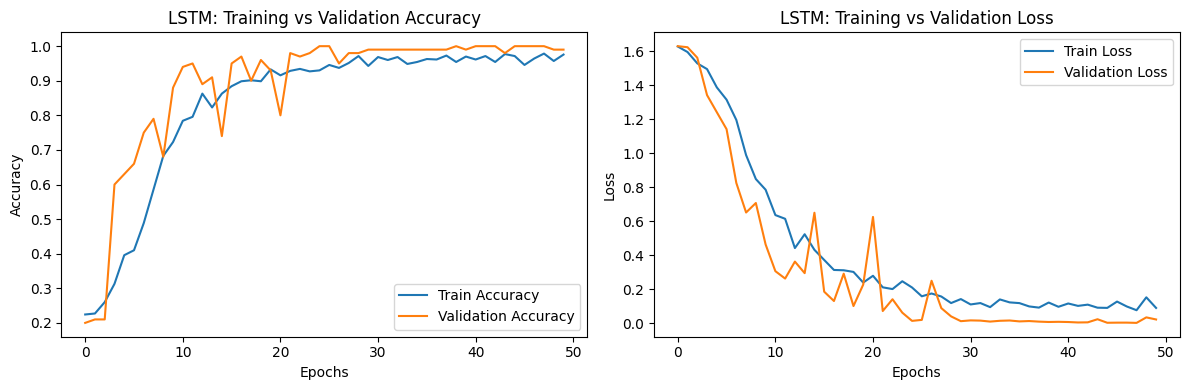

In [20]:
if 'history' in locals():
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('LSTM: Training vs Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('LSTM: Training vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print('No training history found. Please run the model training cell first.')


## Classification Output

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Class labels for Yaseen Khan dataset
classes = ['Normal', 'MVP', 'MS', 'MR', 'AS']

def evaluate_and_plot_manual(model, X, y, set_name, batch_size=1):
    print(f"\n{'='*20} {set_name.upper()} RESULTS {'='*20}")

    y_true_all = []
    y_pred_all = []

    total_samples = len(X)

    for start in range(0, total_samples, batch_size):
        end = min(start + batch_size, total_samples)

        X_batch = X[start:end].astype('float32')
        y_batch = y[start:end]

        pred_batch = model.predict(X_batch, verbose=0)

        y_pred_all.extend(np.argmax(pred_batch, axis=1))
        y_true_all.extend(np.argmax(y_batch, axis=1))

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)

    acc = accuracy_score(y_true_all, y_pred_all)
    print(f'{set_name} Accuracy: {acc * 100:.2f}%')

    cm = confusion_matrix(y_true_all, y_pred_all)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=classes,
        yticklabels=classes
    )
    plt.title(f'LSTM Confusion Matrix ({set_name})')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    print(classification_report(
        y_true_all,
        y_pred_all,
        target_names=classes,
        labels=[0, 1, 2, 3, 4],
        zero_division=0
    ))



==================== TRAINING SET RESULTS ====================
Training Set Accuracy: 100.00%


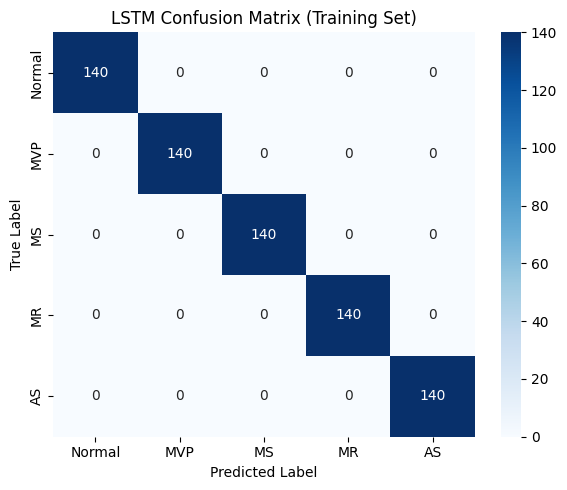

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       140
         MVP       1.00      1.00      1.00       140
          MS       1.00      1.00      1.00       140
          MR       1.00      1.00      1.00       140
          AS       1.00      1.00      1.00       140

    accuracy                           1.00       700
   macro avg       1.00      1.00      1.00       700
weighted avg       1.00      1.00      1.00       700



In [23]:
evaluate_and_plot_manual(model_lstm, X_train_mel, y_train, 'Training Set', batch_size=4)


==================== VALIDATION SET RESULTS ====================
Validation Set Accuracy: 99.00%


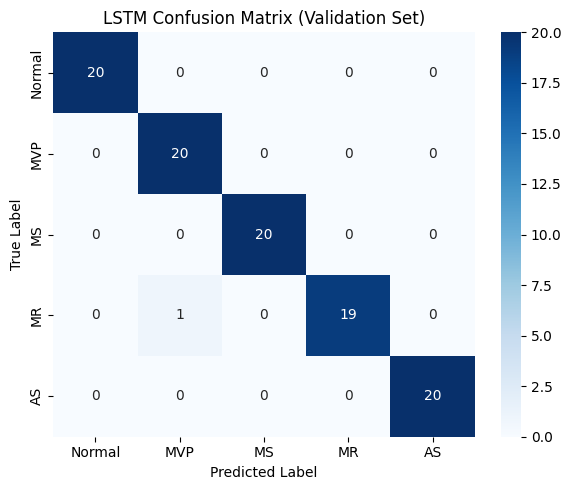

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        20
         MVP       0.95      1.00      0.98        20
          MS       1.00      1.00      1.00        20
          MR       1.00      0.95      0.97        20
          AS       1.00      1.00      1.00        20

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



In [24]:
evaluate_and_plot_manual(model_lstm, X_val_mel,   y_val,   'Validation Set', batch_size=4)


==================== TEST SET RESULTS ====================
Test Set Accuracy: 97.50%


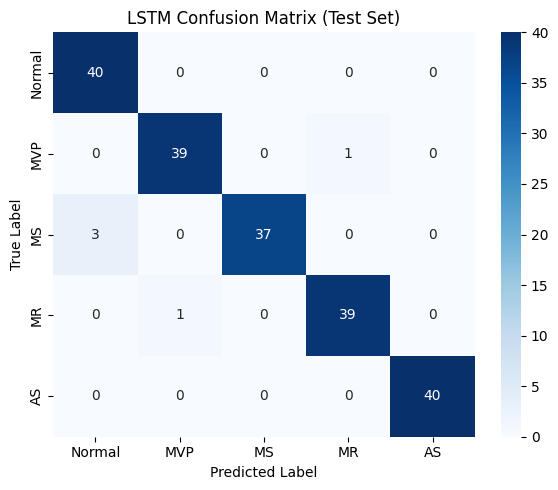

              precision    recall  f1-score   support

      Normal       0.93      1.00      0.96        40
         MVP       0.97      0.97      0.97        40
          MS       1.00      0.93      0.96        40
          MR       0.97      0.97      0.97        40
          AS       1.00      1.00      1.00        40

    accuracy                           0.97       200
   macro avg       0.98      0.97      0.97       200
weighted avg       0.98      0.97      0.97       200



In [25]:
evaluate_and_plot_manual(model_lstm, X_test_mel,  y_test,  'Test Set', batch_size=4)

File: C:\Users\emirh\Downloads\FYP2\Models_Yaseen\Classification-of-Heart-Sound\HeartData\N_New_3주기\New_N_185.wav
Class: Normal


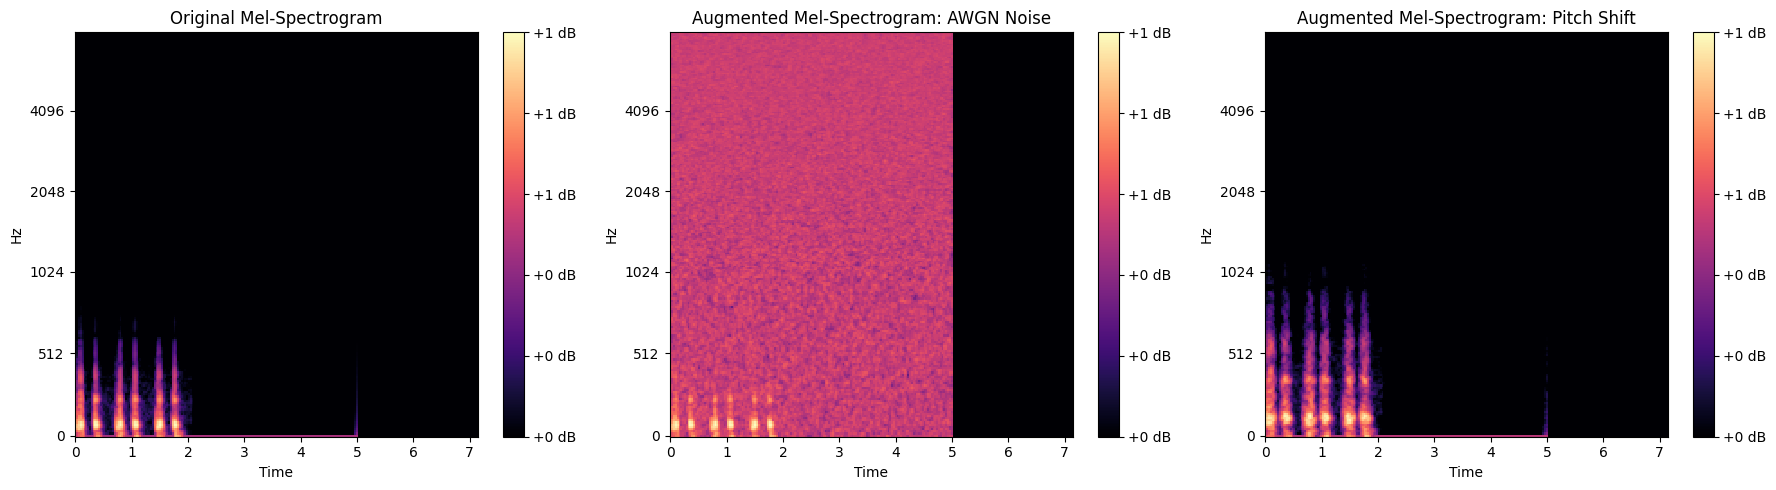

In [26]:
# ============================================================
# VISUALIZE ORIGINAL AND AUGMENTED MEL-SPECTROGRAM
# ============================================================

import librosa.display
import matplotlib.pyplot as plt

# Choose one training audio file
sample_index = 0
sample_path = X_train_paths[sample_index]
sample_label = y_train_labels[sample_index]

print("File:", sample_path)
print("Class:", class_names[sample_label])

# Load audio
y, sr = librosa.load(sample_path, sr=SAMPLE_RATE, duration=DURATION)

# Apply the same preprocessing as the training pipeline
y = butter_bandpass_filter(y, 25, 400, sr)
y = fix_duration_segmentation(y)
y = z_score_normalize(y)

# Generate original Mel-spectrogram
mel_original = extract_features(y, sr)

# Generate augmented audio
y_noise = add_noise_awgn(y)
y_pitch = pitch_shift(y, sr)

# Generate augmented Mel-spectrograms
mel_noise = extract_features(y_noise, sr)
mel_pitch = extract_features(y_pitch, sr)

# Plot original and augmented Mel-spectrograms
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
librosa.display.specshow(
    mel_original.T,
    sr=sr,
    hop_length=HOP_LENGTH,
    x_axis='time',
    y_axis='mel'
)
plt.colorbar(format='%+2.0f dB')
plt.title('Original Mel-Spectrogram')

plt.subplot(1, 3, 2)
librosa.display.specshow(
    mel_noise.T,
    sr=sr,
    hop_length=HOP_LENGTH,
    x_axis='time',
    y_axis='mel'
)
plt.colorbar(format='%+2.0f dB')
plt.title('Augmented Mel-Spectrogram: AWGN Noise')

plt.subplot(1, 3, 3)
librosa.display.specshow(
    mel_pitch.T,
    sr=sr,
    hop_length=HOP_LENGTH,
    x_axis='time',
    y_axis='mel'
)
plt.colorbar(format='%+2.0f dB')
plt.title('Augmented Mel-Spectrogram: Pitch Shift')

plt.tight_layout()
plt.show()